# 03 — Loss: turning "wrong" into a differentiable learning signal

A network cannot optimize a vague statement such as “be more correct.” It needs a scalar objective.

## What you should learn
- the difference between prediction, decision, and loss;
- MSE vs binary cross-entropy (BCE);
- why confident wrong predictions are strongly penalized by BCE;
- how a loss surface gives parameters a landscape to optimize;
- how business cost and training loss are related but **not identical**.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True)
RNG = np.random.default_rng(42)


## 1. One prediction, several losses
For binary classification, BCE is

$$\mathcal L=-[y\log \hat y + (1-y)\log(1-\hat y)]$$


In [2]:
y=1.0
preds=np.array([.01,.1,.25,.5,.75,.9,.99])
mse=(preds-y)**2
bce=-(y*np.log(preds)+(1-y)*np.log(1-preds))
pd.DataFrame({'yhat':preds,'MSE':mse,'BCE':bce})


,yhat,MSE,BCE
0,0.01,0.9801,4.605170
1,0.10,0.8100,2.302585
2,0.25,0.5625,1.386294
3,0.50,0.2500,0.693147
4,0.75,0.0625,0.287682
5,0.90,0.0100,0.105361
6,0.99,0.0001,0.010050


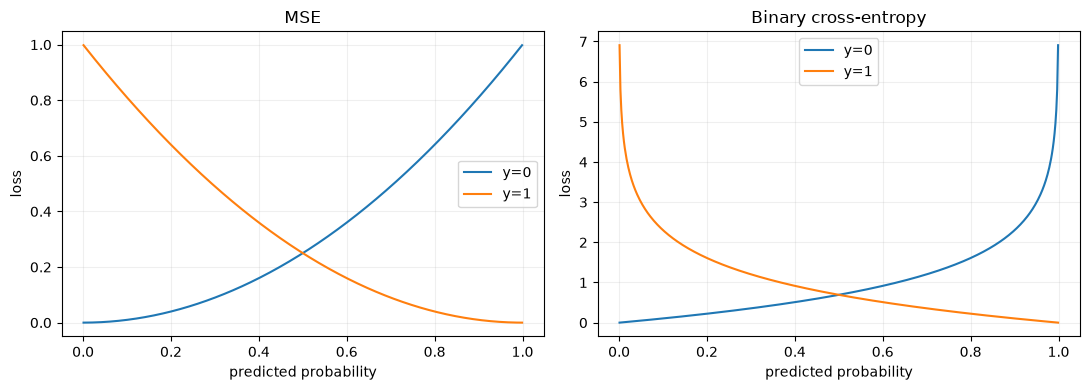

In [3]:
p=np.linspace(.001,.999,500)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for target in [0,1]:
    axes[0].plot(p,(p-target)**2,label=f'y={target}')
    axes[1].plot(p,-(target*np.log(p)+(1-target)*np.log(1-p)),label=f'y={target}')
axes[0].set_title('MSE');axes[1].set_title('Binary cross-entropy')
for ax in axes: ax.set_xlabel('predicted probability');ax.set_ylabel('loss');ax.legend();ax.grid(alpha=.2)
plt.tight_layout();plt.show()


### Inference / insight
BCE expresses an important probabilistic idea: being **confident and wrong** should be much worse than being uncertain and wrong. This makes the loss especially useful when the output is interpreted as a Bernoulli probability.


## 2. A real-data loss surface over weight and bias
We create a single logistic neuron from two real digit features (top ink and bottom ink) for the task digit 0 vs digit 1. Then we scan parameter space.


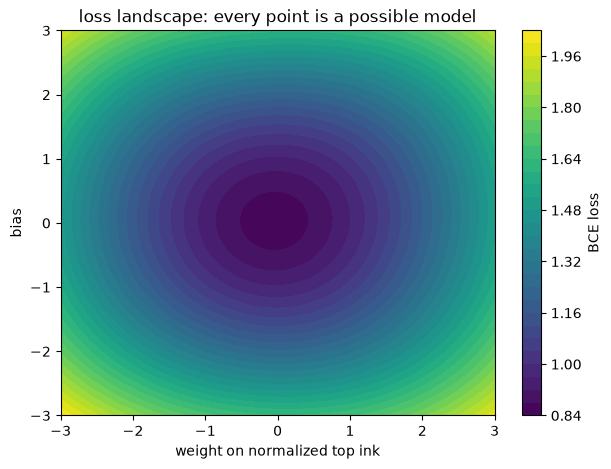

In [4]:
from sklearn.datasets import load_digits
d=load_digits();mask=np.isin(d.target,[0,1]);imgs=d.images[mask];yy=(d.target[mask]==1).astype(float)
X2=np.c_[imgs[:,:4,:].sum((1,2)),imgs[:,4:,:].sum((1,2))]
X2=(X2-X2.mean(0))/X2.std(0)
def batch_bce(w,b):
    s=X2@w+b;p=1/(1+np.exp(-s));eps=1e-9
    return -np.mean(yy*np.log(p+eps)+(1-yy)*np.log(1-p+eps))
ws=np.linspace(-3,3,80);bs=np.linspace(-3,3,80)
W,B=np.meshgrid(ws,bs);L=np.empty_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]): L[i,j]=batch_bce(np.array([W[i,j],1.0]),B[i,j])
fig,ax=plt.subplots(figsize=(7,5))
cs=ax.contourf(W,B,L,levels=30);plt.colorbar(cs,ax=ax,label='BCE loss')
ax.set_xlabel('weight on normalized top ink');ax.set_ylabel('bias');ax.set_title('loss landscape: every point is a possible model');plt.show()


## 3. Training loss vs business cost
Training usually optimizes a smooth surrogate such as BCE. Operations may care about asymmetric consequences such as:

$$\text{business cost}=c_{FP}\cdot FP+c_{FN}\cdot FN$$

Those are different objectives. Training learns a scoring function; policy chooses a threshold to convert scores into actions. We will optimize that policy explicitly in Notebook 11.
